# Setup

In [22]:
import os

PATH_TO_DATASET = '/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data'

lst_files = os.listdir(PATH_TO_DATASET)

for f_name in lst_files:
    print(f_name)

dna_10.txt
dna_40.txt
dna_20.txt
dna_80.txt
dna_160.txt
dna_640.txt
dna_1280.txt
dna_320.txt


In [23]:
PATH_FILES = [os.path.join(PATH_TO_DATASET, i) for i in lst_files]

for f_path in PATH_FILES:
    print(f_path)

/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_10.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_40.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_20.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_80.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_160.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_640.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_1280.txt
/home/trong-thanh/Documents/DAA/DNA Matching/dataset/artificial data/dna_320.txt


In [24]:
import ast

input_strings = []
patterns = []
num_of_misses = []
result = []


for f_path in PATH_FILES:
    with open(f_path, 'r') as f:
        lines = f.readlines()

        for line in lines:
            line = line.strip()
            elements = line.split(' ', maxsplit=3)
            
            input_strings.append(elements[0])
            patterns.append(elements[1])
            num_of_misses.append(int(elements[2]))
            result.append(ast.literal_eval(elements[3]))

In [25]:
import random

seed = 42
n_samples = 10

random.seed(seed)

indices = random.sample(range(len(input_strings)), min(n_samples, len(input_strings)))

print('Example:')

for idx, i in enumerate(indices, start=1):
    print(f"Sample {idx}:")
    print("Input string:", input_strings[i])
    print("Pattern:", patterns[i])
    print("Num of misses:", num_of_misses[i])
    print("Result:", result[i])
    print("-" * 50)

Example:
Sample 1:
Input string: AACTAAGTCTGATTGCTGGCGAGTATTTGTCCCTTAACGG
Pattern: GTCT
Num of misses: 0
Result: [6]
--------------------------------------------------
Sample 2:
Input string: CAGGTTTTAC
Pattern: GGT
Num of misses: 1
Result: [2, 3]
--------------------------------------------------
Sample 3:
Input string: AGCTTCCCGCCAATGGTCAGAAGGCGGTGTTTAGCTAAGGCGGTGAAACTCACCTTCTTACTTGGTCAGGAGCCCGTCTC
Pattern: GCTTCTTT
Num of misses: 2
Result: [52]
--------------------------------------------------
Sample 4:
Input string: GACGAGCTTTTTTTCGTCGCTTGACTCTTTACGCGTGCCCCTAGACCCATGTAGAAATTCAGAGACTCTCGGCCACTGGT
Pattern: CGTGCCCC
Num of misses: 0
Result: [33]
--------------------------------------------------
Sample 5:
Input string: TAGAGTTGCACAGGGCACCG
Pattern: GGC
Num of misses: 0
Result: [13]
--------------------------------------------------
Sample 6:
Input string: TCAAAGCCGCACGCGTGTATTATATAGTATGGAGGCCCAA
Pattern: CCAA
Num of misses: 0
Result: [36]
---------------------------------------------

# Experiment

In [26]:
def valid(pred, expected):
    return sorted(pred) == sorted(expected)

def print_random_samples(input_strings, patterns, num_of_misses, result, seed=42, n_samples=10):
    random.seed(seed)

    indices = random.sample(
        range(len(input_strings)),
        min(n_samples, len(input_strings))
    )

    print(f"{len(indices)} sample with seed = {seed}")
    print()

    for idx, i in enumerate(indices, start=1):
        print(f"Sample {idx}")
        print("Text       :", input_strings[i])
        print("Pattern    :", patterns[i])
        print("k          :", num_of_misses[i])
        print("Expected   :", result[i])
        print()


print_random_samples(
    input_strings,
    patterns,
    num_of_misses,
    result,
    seed=42,
    n_samples=10
)

10 sample with seed = 42

Sample 1
Text       : AACTAAGTCTGATTGCTGGCGAGTATTTGTCCCTTAACGG
Pattern    : GTCT
k          : 0
Expected   : [6]

Sample 2
Text       : CAGGTTTTAC
Pattern    : GGT
k          : 1
Expected   : [2, 3]

Sample 3
Text       : AGCTTCCCGCCAATGGTCAGAAGGCGGTGTTTAGCTAAGGCGGTGAAACTCACCTTCTTACTTGGTCAGGAGCCCGTCTC
Pattern    : GCTTCTTT
k          : 2
Expected   : [52]

Sample 4
Text       : GACGAGCTTTTTTTCGTCGCTTGACTCTTTACGCGTGCCCCTAGACCCATGTAGAAATTCAGAGACTCTCGGCCACTGGT
Pattern    : CGTGCCCC
k          : 0
Expected   : [33]

Sample 5
Text       : TAGAGTTGCACAGGGCACCG
Pattern    : GGC
k          : 0
Expected   : [13]

Sample 6
Text       : TCAAAGCCGCACGCGTGTATTATATAGTATGGAGGCCCAA
Pattern    : CCAA
k          : 0
Expected   : [36]

Sample 7
Text       : ATGGCCCCAGACTAACTCACAAACGGCCGTTCTTGGCCGG
Pattern    : GCCG
k          : 0
Expected   : [25, 35]

Sample 8
Text       : CTGTACAATTTGAAGACCACGAGGCGGCCGAACTGGTAGGTACGCTGCGTGAGTGGCTTTCAATCGATGTCTTCTCGAACCGTTGCCGGGTATCCAAACTTAGCAT

In [27]:
import pandas as pd

def test_algorithm_on_file(algo, f_path):
    records = []

    for i in range(len(input_strings)):
        text = input_strings[i]
        pattern = patterns[i]
        k = num_of_misses[i]
        expected = result[i]

        eval_result = algo.evaluate(text, pattern, k)
        pred = eval_result["matches"]

        records.append({
            "file": os.path.basename(f_path),
            "input_size": len(text),
            "sample_id": i,
            "algorithm": algo.name,
            "text_len": len(text),
            "pattern_len": len(pattern),
            "k": k,
            "runtime_sec": eval_result["runtime_sec"],
            "num_expected": len(expected),
            "num_pred": eval_result["num_matches"],
            "valid": valid(pred, expected),
            "expected": expected,
            "pred": pred,
        })

    return pd.DataFrame(records)

In [28]:
from boyer_moore import BoyerMooreWithVerification
algo = BoyerMooreWithVerification()

all_dfs = []

for f_path in PATH_FILES:
    df_file = test_algorithm_on_file(algo, f_path)
    all_dfs.append(df_file)

df_all = pd.concat(all_dfs, ignore_index=True)

df_all.head()

,file,input_size,sample_id,algorithm,text_len,pattern_len,k,runtime_sec,num_expected,num_pred,valid,expected,pred
0,dna_10.txt,10,0,Boyer-Moore with Verification,10,3,0,0.000011,1,1,True,[1],[1]
1,dna_10.txt,10,1,Boyer-Moore with Verification,10,3,0,0.000009,1,1,True,[3],[3]
2,dna_10.txt,10,2,Boyer-Moore with Verification,10,3,0,0.000006,1,1,True,[6],[6]
3,dna_10.txt,10,3,Boyer-Moore with Verification,10,3,1,0.000020,2,2,True,"[2, 3]","[2, 3]"
4,dna_10.txt,10,4,Boyer-Moore with Verification,10,3,0,0.000007,1,1,True,[1],[1]


In [29]:
summary = df_all.groupby("input_size").agg(
    num_samples=("sample_id", "count"),
    num_correct=("valid", "sum"),
    avg_runtime_sec=("runtime_sec", "mean"),
    median_runtime_sec=("runtime_sec", "median"),
    min_runtime_sec=("runtime_sec", "min"),
    max_runtime_sec=("runtime_sec", "max"),
    total_runtime_sec=("runtime_sec", "sum"),
    avg_pattern_len=("pattern_len", "mean"),
    avg_k=("k", "mean"),
).reset_index()

summary["num_wrong"] = summary["num_samples"] - summary["num_correct"]
summary["accuracy"] = summary["num_correct"] / summary["num_samples"]

summary

,input_size,num_samples,num_correct,avg_runtime_sec,median_runtime_sec,min_runtime_sec,max_runtime_sec,total_runtime_sec,avg_pattern_len,avg_k,num_wrong,accuracy
0,10,80,80,0.000010,0.000007,0.000004,0.000047,0.000817,3.0,0.3,0,1.0
1,20,80,80,0.000012,0.000008,0.000006,0.000052,0.000995,3.0,0.3,0,1.0
2,40,80,80,0.000014,0.000010,0.000008,0.000048,0.001139,4.0,0.2,0,1.0
3,80,80,80,0.000033,0.000030,0.000009,0.000103,0.002607,8.0,0.7,0,1.0
4,160,80,80,0.000186,0.000181,0.000039,0.000621,0.014845,16.0,3.5,0,1.0
5,320,80,80,0.000578,0.000559,0.000129,0.001497,0.046239,32.0,6.5,0,1.0
6,640,80,80,0.002118,0.001734,0.000239,0.006471,0.169474,64.0,11.9,0,1.0
7,1280,80,80,0.009155,0.007261,0.001500,0.024983,0.732427,128.0,25.7,0,1.0


In [30]:
def show_random_samples(df_all, seed=42, n_samples=10):
    random.seed(seed)

    indices = random.sample(
        list(df_all.index),
        min(n_samples, len(df_all))
    )

    for idx, row_id in enumerate(indices, start=1):
        row = df_all.loc[row_id]

        print(f"Sample {idx}")
        print("File       :", row["file"])
        print("Input size :", row["input_size"])
        print("Text len   :", row["text_len"])
        print("Pattern len:", row["pattern_len"])
        print("k          :", row["k"])
        print("Expected   :", row["expected"])
        print("Predicted  :", row["pred"])
        print("Runtime    :", row["runtime_sec"])
        print("Valid      :", row["valid"])
        print("-" * 80)


show_random_samples(df_all, seed=42, n_samples=10)

Sample 1
File       : dna_40.txt
Input size : 80
Text len   : 80
Pattern len: 8
k          : 2
Expected   : [22, 38]
Predicted  : [22, 38]
Runtime    : 6.914400000823662e-05
Valid      : True
--------------------------------------------------------------------------------
Sample 2
File       : dna_10.txt
Input size : 20
Text len   : 20
Pattern len: 3
k          : 1
Expected   : [4, 5, 10, 11]
Predicted  : [4, 5, 10, 11]
Runtime    : 3.3803999940573703e-05
Valid      : True
--------------------------------------------------------------------------------
Sample 3
File       : dna_80.txt
Input size : 160
Text len   : 160
Pattern len: 16
k          : 5
Expected   : [48]
Predicted  : [48]
Runtime    : 0.0003013700006704312
Valid      : True
--------------------------------------------------------------------------------
Sample 4
File       : dna_80.txt
Input size : 40
Text len   : 40
Pattern len: 4
k          : 0
Expected   : [4]
Predicted  : [4]
Runtime    : 1.1383999662939459e-05
Valid   

In [31]:
wrong_df = df_all[df_all["valid"] == False]

print("Số mẫu sai:", len(wrong_df))

wrong_df[[
    "file",
    "input_size",
    "sample_id",
    "pattern_len",
    "k",
    "expected",
    "pred",
    "runtime_sec"
]].head(10)

Số mẫu sai: 0


,file,input_size,sample_id,pattern_len,k,expected,pred,runtime_sec


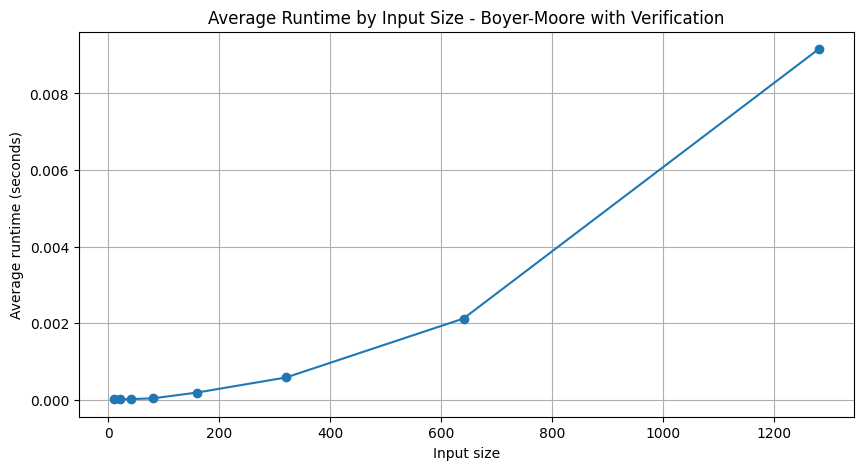

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["avg_runtime_sec"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Average runtime (seconds)")
plt.title(f"Average Runtime by Input Size - {algo.name}")
plt.grid(True)
plt.show()

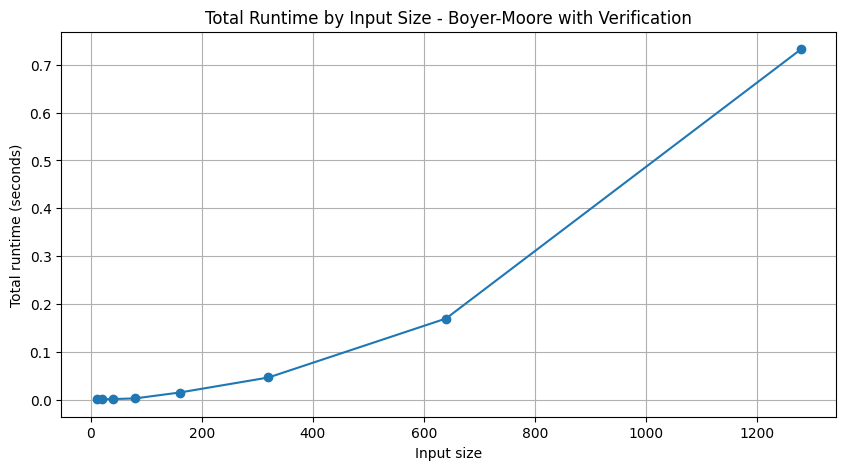

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["total_runtime_sec"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Total runtime (seconds)")
plt.title(f"Total Runtime by Input Size - {algo.name}")
plt.grid(True)
plt.show()

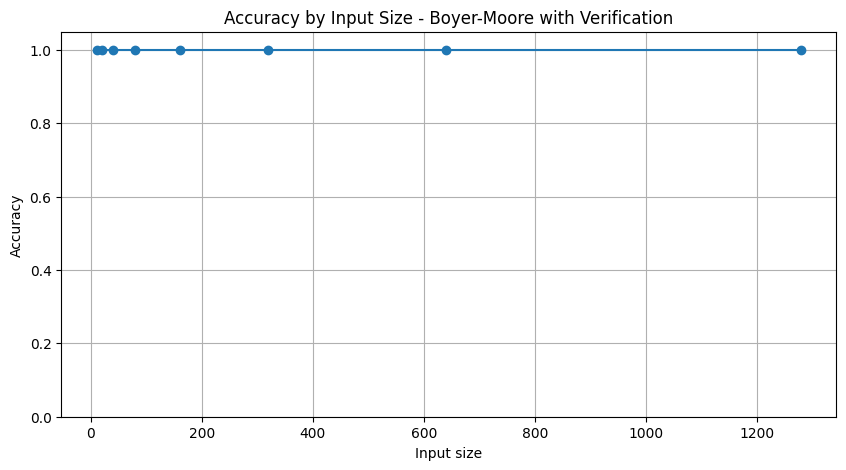

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(summary["input_size"], summary["accuracy"], marker="o")
plt.xlabel("Input size")
plt.ylabel("Accuracy")
plt.title(f"Accuracy by Input Size - {algo.name}")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

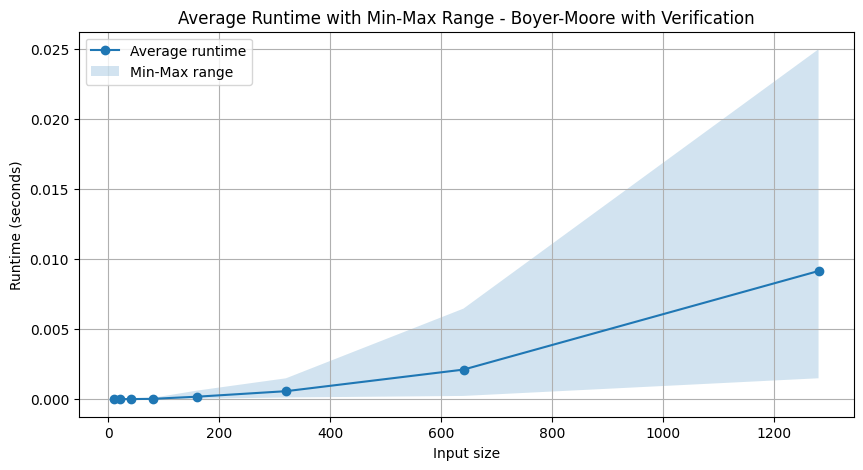

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    summary["input_size"],
    summary["avg_runtime_sec"],
    marker="o",
    label="Average runtime"
)

plt.fill_between(
    summary["input_size"],
    summary["min_runtime_sec"],
    summary["max_runtime_sec"],
    alpha=0.2,
    label="Min-Max range"
)

plt.xlabel("Input size")
plt.ylabel("Runtime (seconds)")
plt.title(f"Average Runtime with Min-Max Range - {algo.name}")
plt.grid(True)
plt.legend()
plt.show()